In [ ]:
 # Required packages
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split



```
de → 0
es → 1
fr → 2
it → 3
```



#Premilinary Analysis


In [ ]:
# this has both L2 and TR from previous experiments

df = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/Implementation/TR1%20and%20L2/L2_TR.csv")

df = df.drop(columns=["Unnamed: 0","sentlength","alang","akorp","afile"],axis = "columns")
df = df.rename(columns={"astatus": "dataset_name"})

num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)

# Count of L1 per L2
count_per_L2 = df.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)

# Data balancing across entire data set
L2 = df[df['dataset_name'] == 'L2']
TR1 = df[df['dataset_name'] == 'TR']


""" concating lets do it afterwards!
df_balanced_1100 = pd.concat([df_L2, df_TR_downsampled_1100], ignore_index=True)"""


# Europarl data

TR2 = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/Data%20Generation/Datasets/europarl/europarl_all_data.csv")

TR2 = TR2.drop(columns="sentlength",axis = "columns")
TR2 = TR2.drop(columns=["Unnamed: 0","alang","akorp","afile","astatus"],axis = "columns")


num_cols = TR2.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)

# smallest sample in Europarl is of 272 (Es) hence downsampling every data
TR1 = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

L2 = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)


TR2 = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)
TR1["dataset_name"] = "TR1"
TR2["dataset_name"] = "TR2"
L2["dataset_name"] = "L2"


df = pd.concat([TR1, L2, TR2], axis=0, ignore_index=True)

Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']
L1               de     es     fr    it
dataset_name                           
L2             1100   1100   1100  1100
TR            27743  18604  89626  2167
Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs',

In [ ]:
df

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
0,TR1,0.020000,0.010000,0.003333,0.666667,0.111111,0.333333,0.111111,0.0,0.888889,...,3.732067,1.834019,0.105556,0.142593,0.195767,0.066667,0.179894,0.031746,0.166667,de
1,TR1,0.006479,0.002160,0.000000,0.600000,0.000000,0.266667,0.000000,0.0,0.266667,...,3.724938,1.863620,0.115556,0.118889,0.224444,0.000000,0.224444,0.000000,0.116667,de
2,TR1,0.006742,0.000000,0.000000,0.850000,0.000000,0.200000,0.000000,0.0,0.500000,...,3.426039,1.503815,0.100000,0.045833,0.187500,0.000000,0.120833,0.012500,0.083333,de
3,TR1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,2.900000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,de
4,TR1,0.006667,0.010000,0.000000,1.000000,0.000000,0.083333,0.000000,0.0,0.333333,...,3.589192,1.420418,0.027778,0.061111,0.244444,0.044444,0.244444,0.016667,0.027778,de
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3259,TR2,0.034853,0.007708,0.000335,1.209877,0.086420,0.358025,0.037037,0.0,0.864198,...,3.935940,1.712908,0.124958,0.305228,0.104746,0.077195,0.067812,0.052538,0.131722,it
3260,TR2,0.026627,0.011095,0.000740,1.217391,0.028986,0.695652,0.057971,0.0,0.695652,...,4.128105,1.725913,0.162302,0.358609,0.063475,0.096894,0.054158,0.077019,0.144065,it
3261,TR2,0.052411,0.011006,0.001048,1.129630,0.111111,0.425926,0.000000,0.0,1.018519,...,3.665000,1.769516,0.101272,0.368335,0.025603,0.099097,0.014029,0.063588,0.105852,it
3262,TR2,0.034467,0.010190,0.001499,1.187817,0.096447,0.543147,0.050761,0.0,0.822335,...,3.863615,1.664220,0.126393,0.385276,0.069967,0.080294,0.057742,0.018584,0.119612,it


In [ ]:
num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]

print("Numeric feature columns:", numerical_cols)


Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']


In [ ]:
print(df.columns.tolist())
print(df.shape)

['dataset_name', 'ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp', 'L1']
(3264, 46)


## Problem with New dataset - Data Imbalance

In [ ]:
l1_values = ["es", "de", "fr", "it"]
df_filtered = df[df["L1"].isin(l1_values)]

# Count of L1 per L2
count_per_L2 = df_filtered.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)



L1             de   es   fr   it
dataset_name                    
L2            272  272  272  272
TR1           272  272  272  272
TR2           272  272  272  272


In [ ]:
df_balanced = df
to_drop = [c for c in ['L1','dataset_name','cluster','kmeans_labels'] if c in df_balanced.columns]
feature_cols = [c for c in df_balanced.columns if c not in to_drop]

df_balanced = df_balanced.dropna()
X_s = df_balanced[feature_cols].values
y_balanced = df_balanced['L1'].values  # target: L1

#Feature importance using a tree-based classifier

Text(0.5, 1.0, 'Top 10 Feature Importances using RandomeForestClassifier')

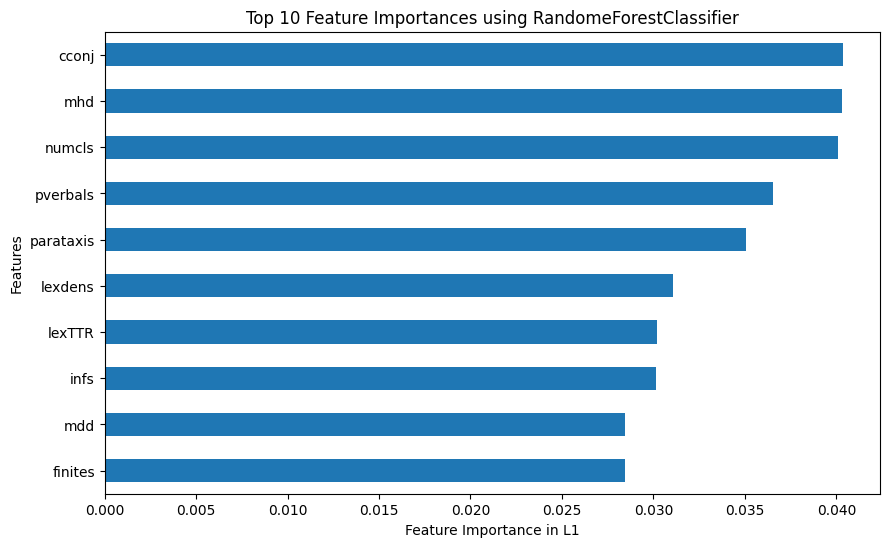

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_s, y_balanced, stratify=y_balanced,random_state=42)
rf = RandomForestClassifier(n_estimators=200).fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
top_features = importances.head(10)[::-1]# reverses the top 20 features for correct horizontal orientation

ax = top_features.plot.barh(figsize=(10,6))
ax.set_xlabel("Feature Importance in L1")   # X-axis label
ax.set_ylabel("Features")             # Y-axis label
ax.set_title("Top 10 Feature Importances using RandomeForestClassifier")


In [ ]:
os.makedirs("/content/plots_RF", exist_ok=True)

# top 10 features
top10_RF = list(top_features.sort_values(ascending=False).head(10).index)

# create the 8-class column correctly
df_plot = df_balanced.copy()
df_plot['class'] = df_plot['dataset_name'].astype(str) + "_" + df_plot['L1'].astype(str)  # e.g. "L2_es"

# classes in correct order
classes = ["L2_es","L2_de","L2_fr","L2_it","TR1_es","TR1_de","TR1_fr","TR1_it","TR2_es","TR2_de","TR2_fr","TR2_it"]

# coerce features to numeric safely
for f in top10_RF:
    df_plot[f] = pd.to_numeric(df_plot[f], errors='coerce')

# create plots and save individually
for feat in top10_RF:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='class', y=feat, data=df_plot, order=classes)
    plt.title(feat)
    plt.xlabel("")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # save each feature individually
    plt.savefig(f"/content/plots_RF/{feat}.png", dpi=300)
    plt.close()   # important to avoid overlap


for feat in top10_RF:
    plt.figure(figsize=(8,4))

    # KDE plot for all classes overlaid
    for cls in classes:
        subset = df_plot[df_plot['class'] == cls]
        if not subset.empty:
            sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4)

    plt.title(f"KDE of {feat} by class")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()

    # save individually
    plt.savefig(f"/content/plots_RF/{feat}_KDE.png", dpi=300)
    plt.close()


#SelectKBEST

In [ ]:

#selectbest
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_s, y_balanced)
top_idx = selector.get_support(indices=True)
top10_SelectKBEST = [feature_cols[i] for i in top_idx]

print("Top 10 features by ANOVA F-test:", top10_SelectKBEST)

os.makedirs("/content/plots_SelectKBest", exist_ok=True)

# coerce features to numeric safely
for f in top10_SelectKBEST:
    df_plot[f] = pd.to_numeric(df_plot[f], errors='coerce')

# create plots and save individually
for feat in top10_SelectKBEST:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='class', y=feat, data=df_plot, order=classes)
    plt.title(feat)
    plt.xlabel("")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # save each feature individually
    plt.savefig(f"/content/plots_SelectKBest/{feat}.png", dpi=300)
    plt.close()   # important to avoid overlap


for feat in top10_SelectKBEST:
    plt.figure(figsize=(8,4))

    # KDE plot for all classes overlaid
    for cls in classes:
        subset = df_plot[df_plot['class'] == cls]
        if not subset.empty:
            sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4)

    plt.title(f"KDE of {feat} by class")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()

    # save individually
    plt.savefig(f"/content/plots_SelectKBest/{feat}_KDE.png", dpi=300)
    plt.close()


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 10 features by ANOVA F-test: ['cconj', 'relativ', 'attrib', 'lexdens', 'lexTTR', 'numcls', 'simple', 'mhd', 'mdd', 'parataxis']


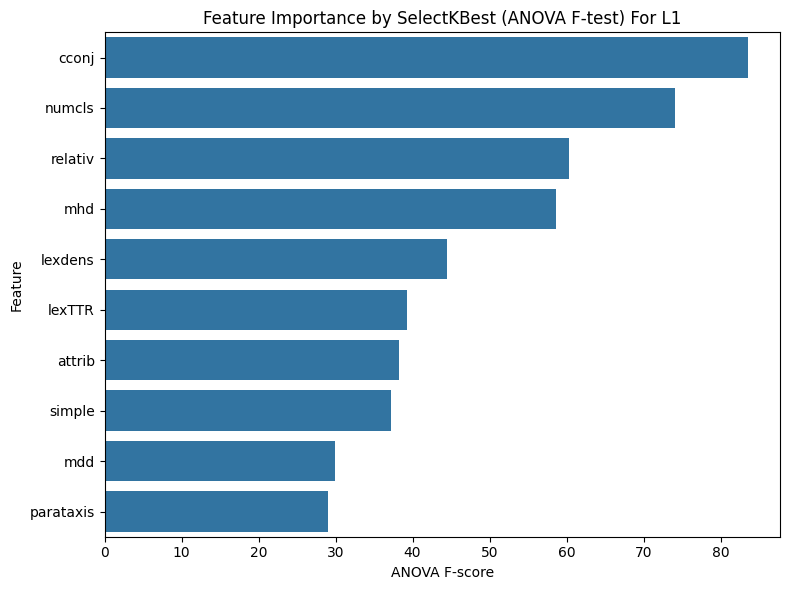

In [ ]:
# Get the F-scores and p-values
f_scores = selector.scores_[top_idx]
p_values = selector.pvalues_[top_idx]

# Sort descending for horizontal bar plot
importance_df = pd.DataFrame({
    'Feature': top10_SelectKBEST,
    'F_score': f_scores,
    'p_value': p_values
}).sort_values(by='F_score', ascending=False)  # now highest F-score on top

# Plot horizontal bar plot
plt.figure(figsize=(8,6))
sns.barplot(x='F_score', y='Feature', data=importance_df)
plt.xlabel("ANOVA F-score")
plt.ylabel("Feature")
plt.title("Feature Importance by SelectKBest (ANOVA F-test) For L1")
plt.tight_layout()
plt.savefig("./plots_SelectKBest/Top10_Feature_Importance_desc.png", dpi=300)
plt.show()


In [ ]:
!zip -r plots_SelectKBest.zip plots_SelectKBest


updating: plots_SelectKBest/ (stored 0%)
updating: plots_SelectKBest/Top10_Feature_Importance_desc.png (deflated 29%)
updating: plots_SelectKBest/lexdens.png (deflated 19%)
updating: plots_SelectKBest/cconj_KDE.png (deflated 9%)
updating: plots_SelectKBest/lexTTR.png (deflated 20%)
updating: plots_SelectKBest/lexdens_KDE.png (deflated 10%)
updating: plots_SelectKBest/simple.png (deflated 20%)
updating: plots_SelectKBest/numcls_KDE.png (deflated 10%)
updating: plots_SelectKBest/attrib_KDE.png (deflated 8%)
updating: plots_SelectKBest/mhd.png (deflated 21%)
updating: plots_SelectKBest/mhd_KDE.png (deflated 9%)
updating: plots_SelectKBest/lexTTR_KDE.png (deflated 15%)
updating: plots_SelectKBest/numcls.png (deflated 20%)
updating: plots_SelectKBest/mdd_KDE.png (deflated 10%)
updating: plots_SelectKBest/mdd.png (deflated 21%)
updating: plots_SelectKBest/cconj.png (deflated 21%)
updating: plots_SelectKBest/parataxis.png (deflated 17%)
updating: plots_SelectKBest/simple_KDE.png (deflated 7%)

In [ ]:
!zip -r plots_RF.zip plots_RF

updating: plots_RF/ (stored 0%)
updating: plots_RF/lexdens.png (deflated 19%)
updating: plots_RF/cconj_KDE.png (deflated 9%)
updating: plots_RF/lexTTR.png (deflated 20%)
updating: plots_RF/lexdens_KDE.png (deflated 10%)
updating: plots_RF/numcls_KDE.png (deflated 10%)
updating: plots_RF/mhd.png (deflated 21%)
updating: plots_RF/mhd_KDE.png (deflated 9%)
updating: plots_RF/infs_KDE.png (deflated 9%)
updating: plots_RF/lexTTR_KDE.png (deflated 15%)
updating: plots_RF/numcls.png (deflated 20%)
updating: plots_RF/infs.png (deflated 19%)
updating: plots_RF/mdd_KDE.png (deflated 10%)
updating: plots_RF/mdd.png (deflated 21%)
updating: plots_RF/cconj.png (deflated 21%)
updating: plots_RF/pverbals.png (deflated 19%)
updating: plots_RF/finites.png (deflated 18%)
updating: plots_RF/finites_KDE.png (deflated 9%)
updating: plots_RF/parataxis.png (deflated 17%)
updating: plots_RF/pverbals_KDE.png (deflated 9%)
updating: plots_RF/parataxis_KDE.png (deflated 11%)
